<a href="https://colab.research.google.com/github/shamikkarkhanis/csci4170-paiml/blob/main/hw6_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Flow Matching
- Source 1: https://arxiv.org/pdf/2210.02747
- Source 2: https://mlg.eng.cam.ac.uk/blog/2024/01/20/flow-matching.html


### Problem: standard diffusion faces an issue where models need to follow curved paths to translate noise to the expected image. These curves become difficult to follow when the model is overshooting/undershooting the path and forced to compenstate. This leads to longer, potentially unreliable diffusion.

- flow matching aims to solve this by trying to turn these cures into a straight line to turn noise into the expected image. the main architecture involved in this process us U-net which takes in the current image state, the time step, and the original prompt, then outputs a velocity vector.

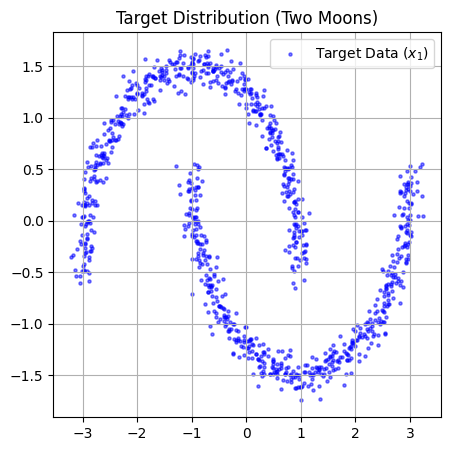

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

torch.manual_seed(42)
np.random.seed(42)

def get_data(batch_size):
    x, _ = make_moons(n_samples=batch_size, noise=0.05)
    x = (x - np.array([0.5, 0.25])) * 2
    return torch.tensor(x, dtype=torch.float32)

data_samples = get_data(1000)
plt.figure(figsize=(5, 5))
plt.scatter(data_samples[:, 0], data_samples[:, 1], s=5, alpha=0.5, c='blue', label='Target Data ($x_1$)')
plt.title("Target Distribution (Two Moons)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
class VectorFieldNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, t):
        t_input = t.expand(-1, 2)
        x_t = torch.cat([x, t], dim=-1)
        return self.net(x_t)

model = VectorFieldNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [7]:
epochs = 3000
batch_size = 512

for step in range(epochs):
    # Sample noise x_0 and data x_1
    x_0 = torch.randn(batch_size, 2)
    x_1 = get_data(batch_size)

    # Sample time t uniformly in [0, 1]
    t = torch.rand(batch_size, 1)

    # Compute straight line path
    x_t = (1 - t) * x_0 + t * x_1

    # target vector field - velocity
    target_v = x_1 - x_0

    # Predict vector field and compute loss
    pred_v = model(x_t, t)
    loss = torch.mean((pred_v - target_v)**2)

    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 500 == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.4f}")


Step    0 | Loss: 3.1442
Step  500 | Loss: 2.0016
Step 1000 | Loss: 2.0455
Step 1500 | Loss: 1.9326
Step 2000 | Loss: 1.8129
Step 2500 | Loss: 1.9562


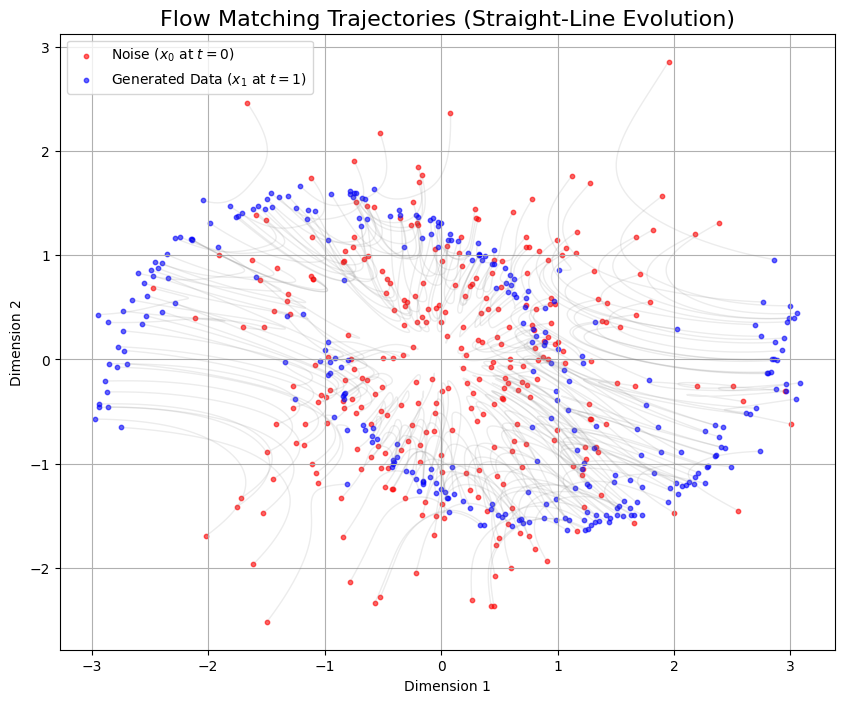

In [10]:
def euler_solve(model, n_samples=300, n_steps=50):
    model.eval()
    with torch.no_grad():
        # noise
        x_t = torch.randn(n_samples, 2)
        dt = 1.0 / n_steps

        trajectories = [x_t.clone()]

        for i in range(n_steps):
            t = torch.ones(n_samples, 1) * (i * dt)
            v = model(x_t, t)
            # Euler step: x_{t+dt} = x_t + v * dt
            x_t = x_t + v * dt
            trajectories.append(x_t.clone())

    return torch.stack(trajectories)

trajectories = euler_solve(model)

plt.figure(figsize=(10, 8))
for i in range(trajectories.shape[1]):
    plt.plot(trajectories[:, i, 0], trajectories[:, i, 1], color='gray', alpha=0.15, linewidth=1)

plt.scatter(trajectories[0, :, 0], trajectories[0, :, 1], color='red', s=10, alpha=0.6, label='Noise ($x_0$ at $t=0$)')
plt.scatter(trajectories[-1, :, 0], trajectories[-1, :, 1], color='blue', s=10, alpha=0.6, label='Generated Data ($x_1$ at $t=1$)')

plt.title("Flow Matching Trajectories (Straight-Line Evolution)", fontsize=16)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

Average Nearest Neighbor Distance (50 steps):  0.0413
Average Nearest Neighbor Distance (1000 steps): 0.0358


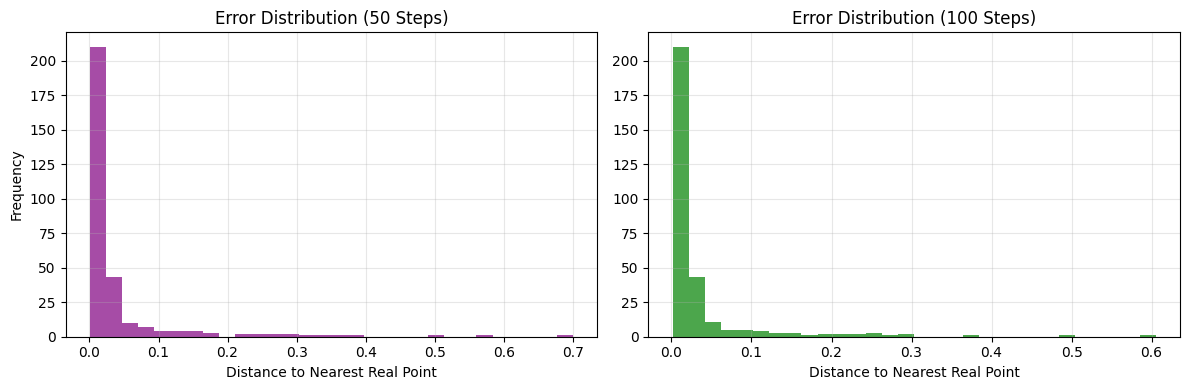

In [16]:
trajectories_100 = euler_solve(model, n_steps=1000)
generated_data_100 = trajectories_100[-1].numpy()

distances_100, _ = nn_model.kneighbors(generated_data_100)
mean_distance_100 = np.mean(distances_100)

print(f"Average Nearest Neighbor Distance (50 steps):  {mean_distance:.4f}")
print(f"Average Nearest Neighbor Distance (1000 steps): {mean_distance_100:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(distances, bins=30, color='purple', alpha=0.7)
plt.title("Error Distribution (50 Steps)")
plt.xlabel("Distance to Nearest Real Point")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(distances_100, bins=30, color='green', alpha=0.7)
plt.title("Error Distribution (100 Steps)")
plt.xlabel("Distance to Nearest Real Point")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Limitations
- Semantic Collision: when we deal with high dimentional spaces, the straight lines from different points can intersect. This can lead to the model to get mixed up and switch the generation. Blue sky and red fire might become a purple house.
- Deterministic Bias: when using flow matching compared to standard stochastic diffusion results can be less creative due to flow mathing being deterministic. This is due to the lack of guassian noise being injected at each step which leads to a mathematically direct way. Instead of predicting the noise at each step flow matching predicts the differential equation which leads to the solution directly.

### Experiment improvements
- It would be cool to see the direction of the velocity vectors from the initial time step to the end. As FM should give us a direct path from the start to the end we would expect the two veloctiy vectors to point in the same direction (cosine similarity of 1)